In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from qtl.norm import deseq2_normalized_counts
from sklearn.decomposition import PCA

from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

from figure_params import disease_colors

In [15]:
def ranksum_df(df, test_field, value_field, groupby):
    vals = df[test_field].unique()
    if len(vals) != 2:
        print("Error, there must be two unique categories to test")
        return None
    
    # Define a helper to return both values as a Series
    def perform_ranksum(x):
        group1 = x.loc[x[test_field] == vals[0], value_field]
        group2 = x.loc[x[test_field] == vals[1], value_field]
        stat, p = ranksums(group1, group2)
        return pd.Series({'stat': stat, 'p': p})

    # Apply the helper and expand into columns
    res = df.groupby(groupby).apply(perform_ranksum)
    
    # Calculate FDR-adjusted p-values (q-values)
    res['q'] = multipletests(res['p'], method='fdr_bh')[1]
    
    # Sort by significance
    res = res.sort_values('p')
    return res

## Figure 2A - PCA of bulk data

In [6]:
X = pd.read_csv('../data/bulk_RNA_gene_expression_matrix.csv.gz',index_col='gene_name')
S = pd.read_csv('../data/bulk_metadata.txt',index_col='sample',sep='\t')

S = S[S['disease'].isin(['FL','tFL'])]
X = X.loc[:,S.index]

### Filter to protein coding genes

In [8]:
g = pd.read_csv('../ref/gencode.v19.genes.v7.patched_contigs.gtf',
               comment='#',header=None,sep='\t')
g = g[g[2]=='gene']

g[['gene_type','gene_name']] = g[8].str.extract('gene_type "([^"]+)".*gene_name "([^"]+)"')
g = g[g['gene_type'] == 'protein_coding']

X = X[X.index.isin(g['gene_name'])]

/tmp/ipykernel_161232/2405463161.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  g = pd.read_csv('../ref/gencode.v19.genes.v7.patched_contigs.gtf',


### Preprocess and run PCA

In [9]:
## Filter to genes with >10tpm in >20% of samples
#gmean = X.T.mean()
keep_idx = ((X>10).sum(axis=1) > X.shape[1] * .2)

Xfilt = X.loc[keep_idx]

# Use deseq2 normalization
Xnorm = deseq2_normalized_counts(Xfilt)

# Log-transform
Xlog = np.log10(1+Xnorm)

# Center
Xz = (Xlog.T - Xlog.T.mean()).T

# Run PCA
pca = PCA(n_components=5)
col_names = ['PC'+str(i) for i in range(1,6)]
P= pd.DataFrame(pca.fit_transform(Xz.T),index=Xz.columns,columns=col_names)
W = pd.DataFrame(pca.components_.T,index=Xz.index,columns=col_names)


### Test first two components

In [10]:
from hotelling.stats import hotelling_t2

pcs = ['PC1','PC2']
FL = S.index[S['disease']=='FL']
tFL = S.index[S['disease']=='tFL']


p = hotelling_t2(P.loc[FL,pcs],P.loc[tFL,pcs])[2]

### Plot

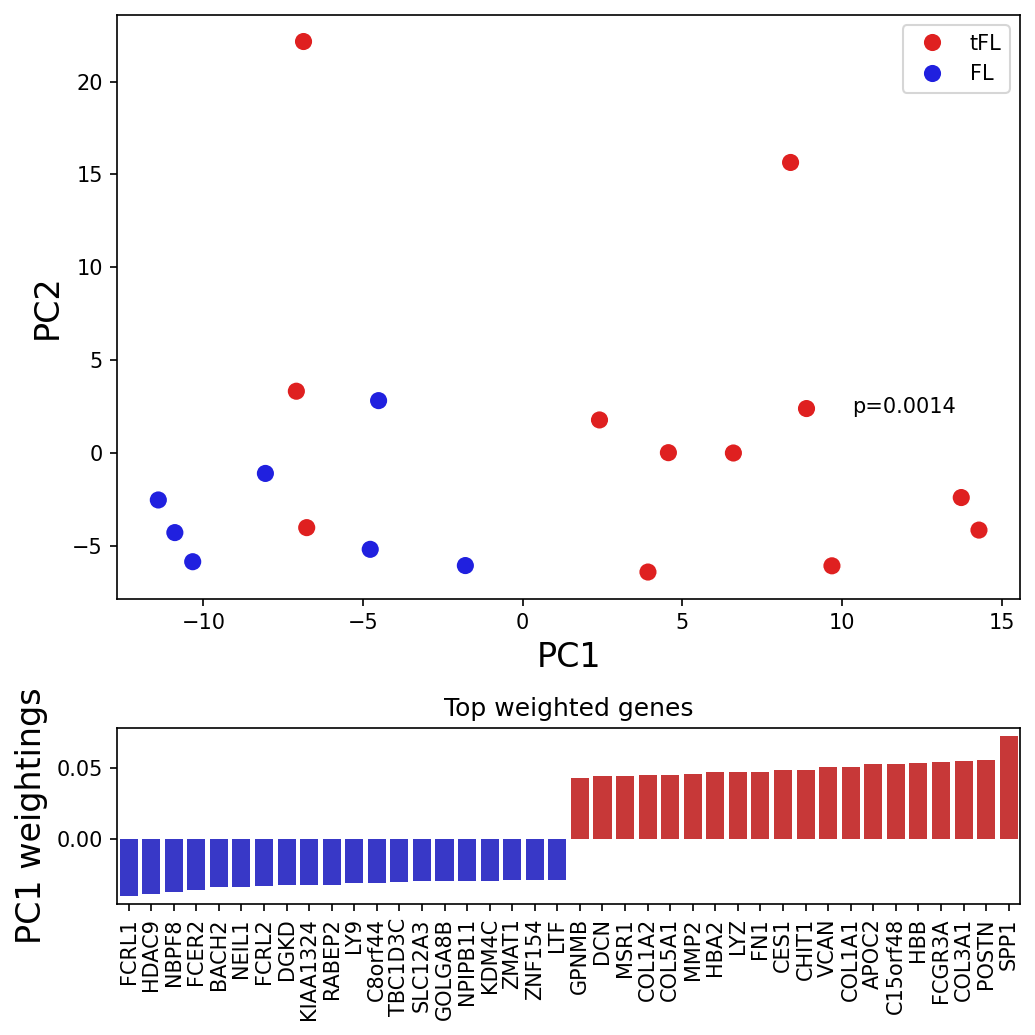

In [11]:
f,ax=plt.subplots(2,1,gridspec_kw={'height_ratios':[1,.3]},figsize=(7,7))
sns.scatterplot(x="PC1",y="PC2",data=P,hue=S['disease'],palette=disease_colors,ax=ax[0],s=80)
ax[0].legend(bbox_to_anchor=(1,1))
ax[0].text(ax[0].get_xlim()[1]-2,ax[0].get_ylim()[0]+10,f"p={p:0.4f}",ha="right")

w = pd.concat([W.sort_values('PC1')[0:20]['PC1'],
               W.sort_values('PC1')[-20:]['PC1']])

hue = pd.Series(np.hstack([np.repeat('FL',20),np.repeat('tFL',20)]),index=w.index)
sns.barplot(x=w.index,
            y=w,ax=ax[1],
           hue = hue,
           dodge=False,palette=disease_colors)
plt.xticks(rotation=90);
ax[1].set_xlabel('')
ax[1].set_ylabel('PC1 weightings')
ax[1].set_title('Top weighted genes')
ax[1].legend().remove()

plt.tight_layout()

## Figure 2B - Cibersort

#### Cibersort was run through the web portal https://cibersortx.stanford.edu/

In [7]:
C = pd.read_csv('../data/CIBERSORTx_FLspecific_signatures_100725.txt',sep='\t').set_index('Mixture')

In [8]:
C['disease'] = S['disease']
C = C[C['disease'].isin(['FL','tFL'])]

In [9]:
Cdf = C.iloc[:,0:12].reset_index().melt(id_vars='Mixture',var_name='cell_type',value_name='score')
Cdf['frac']=Cdf.groupby('Mixture')['score'].transform(lambda x : x/x.sum())
Cdf['disease'] = Cdf.join(S,on='Mixture')['disease']

In [10]:
Cdf

,Mixture,cell_type,score,frac,disease
0,CAR_003_FFPE_01,T-naive,0.000000,0.000000,tFL
1,CAR_004_FFPE_01,T-naive,0.012866,0.012866,tFL
2,CAR_006_FFPE_01,T-naive,0.021192,0.021192,tFL
3,CAR_013_FFPE_01,T-naive,0.000000,0.000000,FL
4,CAR_015_FFPE_01,T-naive,0.000000,0.000000,tFL
...,...,...,...,...,...
223,CAR_067_FFPE_01,pDC,0.024963,0.024963,FL
224,CAR_073_FFPE_01,pDC,0.005667,0.005667,FL
225,CAR_075_FFPE_01,pDC,0.000000,0.000000,FL
226,CAR_078_FFPE_01,pDC,0.025146,0.025146,FL


In [16]:
# Only test cell types reaching above 5% in some sample
max_frac = Cdf.groupby('cell_type')['frac'].max()
ct_test = max_frac.index[max_frac>.03]
test_idx = Cdf['cell_type'].isin(ct_test)

res = ranksum_df(Cdf[test_idx],'disease','frac',groupby='cell_type')
res

,stat,p,q
cell_type,,,
FDC,-3.296102,0.000980,0.009804
FRC,2.873524,0.004059,0.017623
Monocyte,2.789009,0.005287,0.017623
Tfh,-2.112886,0.034611,0.086526
Endothelial,1.774824,0.075927,0.151854
mDC,-1.521278,0.128190,0.183129
pDC,-1.521278,0.128190,0.183129
T-naive,0.887412,0.374857,0.468571
Pericyte,0.507093,0.612090,0.672604


In [19]:
#plot_order = ['T-naive','pDC','FDC','mDC','Tfh','Endothelial','NK','FRC','CTL','Monocyte','T-reg']

# Sort by ranksum statistic FL -> tFL
plot_order = list(res.sort_values('stat').index)
Cdf['cell_type'] = pd.Categorical(Cdf['cell_type'],categories=plot_order)
Cdf = Cdf.sort_values('cell_type')

In [20]:
Cdf['disease'] = pd.Categorical(Cdf['disease'],categories=['FL','tFL'])

/tmp/ipykernel_597236/4010635708.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(x="cell_type",y="frac",hue="disease",data=Cdf,color='k',dodge=True)


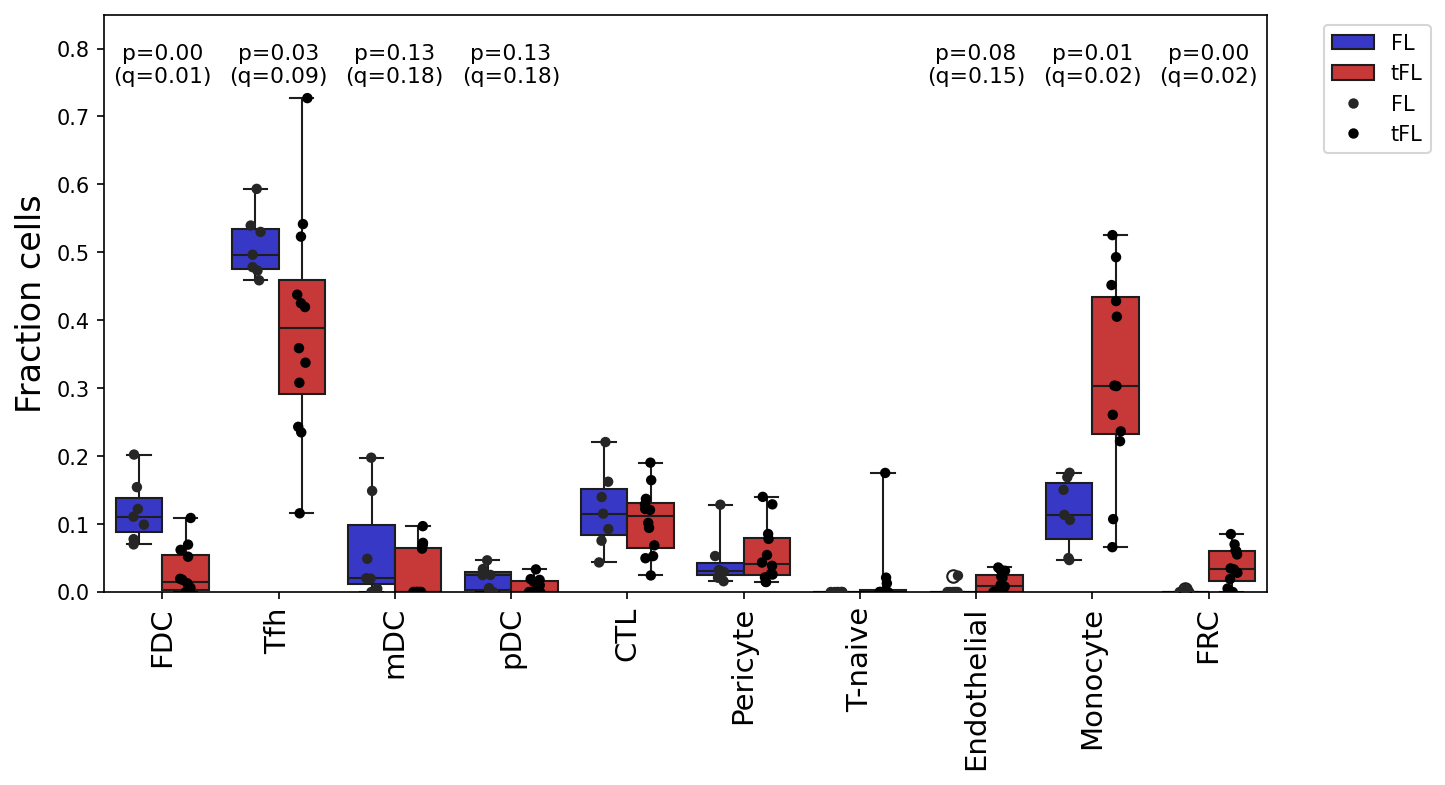

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(x="cell_type",y="frac",hue="disease",data=Cdf,palette=disease_colors,whis=100)
sns.stripplot(x="cell_type",y="frac",hue="disease",data=Cdf,color='k',dodge=True)

plt.xticks(rotation = 90,fontsize=14);
plt.ylabel('Fraction cells')
plt.xlabel('')

for ct,row in res.iterrows():
    if row['q']<.25:
        xpos = plot_order.index(ct)
        plt.text(xpos,.75,f"p={row['p']:.2f}\n(q={row['q']:.2f})",ha='center',fontsize=10.5)
plt.ylim(0,.85)
plt.legend(bbox_to_anchor=(1.15,1))

plt.savefig('pdf/fig2b_cibersort.pdf',bbox_inches='tight')

## Supplementary figure 2B

In [87]:
X = pd.read_csv('../data/bulk_RNA_gene_expression_matrix.csv.gz',index_col='gene_name')
S = pd.read_csv('../data/bulk_metadata.txt',index_col='sample',sep='\t')
C = pd.read_csv('../data/CIBERSORTx_FLspecific_signatures_100725.txt',sep='\t').set_index('Mixture')
C = C[C.index.isin(S.index)]
C['disease'] = S['disease']
S['subtype_cat'] = (S['disease'] + '-' + S['subtype'].fillna('')).str.strip('-')

Cdf = C.iloc[:,0:12].reset_index().melt(id_vars='Mixture',var_name='cell_type',value_name='score')
Cdf['frac']=Cdf.groupby('Mixture')['score'].transform(lambda x : x/x.sum())
Cdf[['disease','subtype']] = Cdf.join(S,on='Mixture')[['disease','subtype_cat']]

In [88]:
# Only test cell types reaching above 5% in some sample
max_frac = Cdf.groupby('cell_type')['frac'].max()
ct_test = max_frac.index[max_frac>.03]
test_idx = Cdf['cell_type'].isin(ct_test)

res = ranksum_df(Cdf[test_idx&(Cdf['disease'].isin(['tFL','DLBCL']))],'disease','frac',groupby='cell_type')
res

,stat,p,q
cell_type,,,
FRC,2.081195,0.037416,0.374161
Endothelial,-1.726949,0.084177,0.420884
Pericyte,1.195580,0.231860,0.719752
Tfh,1.062738,0.287901,0.719752
T-naive,-0.885615,0.375825,0.751650
mDC,0.664211,0.506555,0.840653
Monocyte,-0.487088,0.626196,0.840653
FDC,-0.309965,0.756587,0.840653
pDC,-0.309965,0.756587,0.840653


In [89]:
Cdf.head()

,Mixture,cell_type,score,frac,disease,subtype
0,CAR_003_FFPE_01,T-naive,0.000000,0.000000,tFL,tFL
1,CAR_004_FFPE_01,T-naive,0.012866,0.012866,tFL,tFL
2,CAR_006_FFPE_01,T-naive,0.021192,0.021192,tFL,tFL
3,CAR_007_FFPE_01,T-naive,0.010328,0.010328,DLBCL,DLBCL
4,CAR_011_FFPE_01,T-naive,0.000000,0.000000,DLBCL,DLBCL-nonGCB


In [90]:
ttype_order = ['FL','tFL','DLBCL-GCB','DLBCL-nonGCB']
Cdf = Cdf[Cdf['subtype'].isin(ttype_order)]
Cdf['subtype'] = pd.Categorical(Cdf['subtype'],categories=ttype_order)

/tmp/ipykernel_597236/482214129.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(x="cell_type",y="frac",hue="subtype",data=Cdf,color='k',dodge=True)


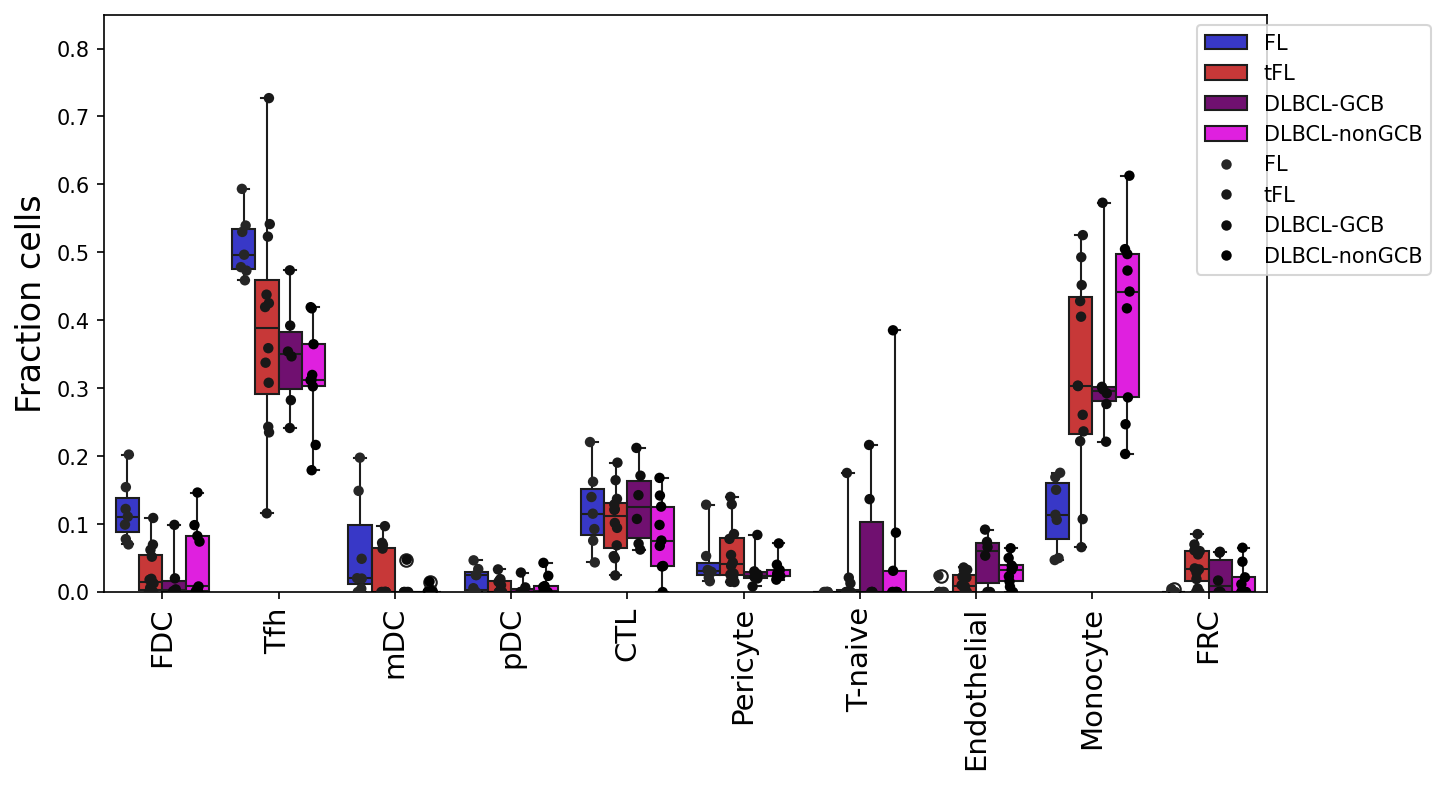

In [91]:
Cdf['cell_type'] = pd.Categorical(Cdf['cell_type'],categories=plot_order)
Cdf = Cdf.sort_values('cell_type')

plt.figure(figsize=(10,5))
sns.boxplot(x="cell_type",y="frac",hue="subtype",data=Cdf,palette=disease_colors,whis=100)
sns.stripplot(x="cell_type",y="frac",hue="subtype",data=Cdf,color='k',dodge=True)

plt.xticks(rotation = 90,fontsize=14);
plt.ylabel('Fraction cells')
plt.xlabel('')

for ct,row in res.iterrows():
    if row['q']<.25:
        xpos = plot_order.index(ct)
        plt.text(xpos,.75,f"p={row['p']:.2f}\n(q={row['q']:.2f})",ha='center',fontsize=10.5)
plt.ylim(0,.85)
plt.legend(bbox_to_anchor=(1.15,1))

plt.savefig('pdf/supplementary_fig2b_cibersort.pdf',bbox_inches='tight')